In [123]:
import pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt, seaborn as sns

url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"

df = pd.read_csv(url)
for col in df.columns:
    print(col)
df.head(5)

eventId
subEventName
tags
playerId
matchId
eventName
teamId
matchPeriod
eventSec
subEventId
id
x1
y1
x2
y2


,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0
1,8,High pass,['Accurate'],Abdullah Ibrahim Otayf,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,4.487814,High pass,258612106,35,53,75.0,19.0
2,1,Air duel,"['Won', 'Accurate']",Ilya Kutepov,"Russia - Saudi Arabia, 5 - 0",Duel,Russia,1H,5.937411,Air duel,258612077,25,81,37.0,83.0
3,1,Air duel,"['Lost', 'Not accurate']",Yasir Gharsan Al Shahrani,"Russia - Saudi Arabia, 5 - 0",Duel,Saudi Arabia,1H,6.406961,Air duel,258612112,75,19,63.0,17.0
4,8,Simple pass,['Accurate'],Salman Mohammed Al Faraj,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,8.562167,Simple pass,258612110,63,17,71.0,15.0


In [124]:
import ast
df["tags"] = df["tags"].apply(ast.literal_eval)

In [125]:
df['eventName'].unique()

<StringArray>
[                   'Pass',                    'Duel',
               'Free Kick',                    'Foul',
      'Others on the ball',                    'Shot',
            'Save attempt',                 'Offside',
 'Goalkeeper leaving line']
Length: 9, dtype: str

In [126]:
uniquetags = set()
for taglist in df["tags"]:
    for tag in taglist:
        uniquetags.add(tag)

uniquetags = {tag for taglist in df["tags"] for tag in taglist}
print(uniquetags)

{'Position: Post center right', 'Second yellow card', 'Position: Goal center left', 'Position: Out center left', 'Won', 'Missed ball', 'Not accurate', 'Assist', 'Opportunity', 'Fairplay', 'Take on left', 'Position: Post center left', 'Head/body', 'Goal', 'Sliding tackle', 'Anticipation', 'Counter attack', 'Feint', 'Position: Post high right', 'Lost', 'Free space right', 'Red card', 'Through', 'Position: Out low right', 'Position: Goal low right', 'Blocked', 'Position: Goal center right', 'Dangerous ball lost', 'Position: Goal high center', 'Position: Out high right', 'Position: Out low left', 'Accurate', 'Anticipated', 'Key pass', 'Position: Out center right', 'Position: Goal center', 'Position: Post high left', 'High', 'Right foot', 'Position: Goal high right', 'Position: Post low left', 'Indirect', 'Interception', 'Position: Goal low center', 'Own goal', 'Take on right', 'Position: Goal low left', 'Position: Out high center', 'Yellow card', 'Position: Post high center', 'Neutral', 'D

In [127]:
df['pass'] = (df['eventName'] == "pass").astype(int)
df['shot'] = (df['eventName'] == "shot").astype(int)
df['goal'] = ((df["eventName"] == "shot") & (df["tags"].apply(lambda l : "goal" in l ))).astype(int)
df['acc_pass'] = ((df["eventName"] == "Pass") & (df["tags"].apply(lambda l: "goal" in l))).astype(int)
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot,goal,acc_pass
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,0,0,0,0


In [128]:
from math import dist

def get_gold_events(row: pd.Series):
    x_len = 120
    y_len = 70
    x1 = (row["x1"] / 100) * x_len
    y1 = (row["y1"] / 100) * y_len
    x2 = x_len
    y2 = y_len / 2
    point1 = [x1,y1]
    point2 = [x2,y2]
    d = dist(point1, point2)
    if d <= 18:
        return 1
    else:
        return 0

    
    
df['gold_event'] = df.apply(get_gold_events, axis = 1)
df.head(1)


,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot,goal,acc_pass,gold_event
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,0,0,0,0,0


In [129]:
df["gold_shot"] = ((df["shot"] ==1) & (df["gold_event"]==1)).astype(int)
df["gold_pass"] = ((df["pass"] ==1) & (df["gold_event"]==1)).astype(int)

In [130]:
grp = df.groupby(["matchId", "teamId"]).agg(
    shots = ("shot", "sum"),
    goals = ("goal", "sum"),
    gold_shots = ("gold_shot", "sum"),
    passes = ("pass", "sum"), 
    acc_passes = ("acc_pass", "sum"),
    gold_passes = ("gold_pass", "sum"),
    gold_events = ("gold_event", "sum"),
).reset_index()
grp["perc_acc_pass"] = grp["acc_passes"] / grp["passes"]
grp["perc_gold_shot"] = grp["gold_shots"] / grp["shots"]
grp

,matchId,teamId,shots,goals,gold_shots,passes,acc_passes,gold_passes,gold_events,perc_acc_pass,perc_gold_shot
0,"Argentina - Croatia, 0 - 3",Argentina,0,0,0,0,0,0,24,NaN,NaN
1,"Argentina - Croatia, 0 - 3",Croatia,0,0,0,0,0,0,19,NaN,NaN
2,"Argentina - Iceland, 1 - 1",Argentina,0,0,0,0,0,0,32,NaN,NaN
3,"Argentina - Iceland, 1 - 1",Iceland,0,0,0,0,0,0,17,NaN,NaN
4,"Australia - Peru, 0 - 2",Australia,0,0,0,0,0,0,37,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,0,0,0,0,0,0,9,NaN,NaN
124,"Uruguay - Russia, 3 - 0",Russia,0,0,0,0,0,0,8,NaN,NaN
125,"Uruguay - Russia, 3 - 0",Uruguay,0,0,0,0,0,0,16,NaN,NaN
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,0,0,0,0,0,0,11,NaN,NaN


In [131]:
def viz_corr(df: pd.DataFrame, x:str , y:str) -> None:
    plt.figure(figsize=(5,3))
    xlabel = x.replace("_", " ").title()
    ylabel = y.replace("_" , " ").title()
    title=f"Correlation Between {xlabel} and {ylabel}"
    r,p = stats.pearsonr(df[x], df[y])
    r2 = r**2
    text = f"""
    r: {r:.4f}
    p: {p: .4f}
    r2: {r2: .4f}"""
    reg = sns.regplot(data = df, x=x, y=y, line_kws={"color": "r", "label": "Line of Best Fit"})
    reg.text(
        0.1,
        0.7,
        text,
        transform = reg.transAxes,
        bbox= {"boxstyle": "round,pad =0.5", "fc": "white"}
    )
    reg.set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.legend()
    plt.show()

In [132]:
grp.corr(numeric_only= True)

,shots,goals,gold_shots,passes,acc_passes,gold_passes,gold_events,perc_acc_pass,perc_gold_shot
shots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
goals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gold_shots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
passes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acc_passes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gold_passes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gold_events,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
perc_acc_pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
perc_gold_shot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/var/folders/3_/17_jhz393j72f4q4hghx47f40000gn/T/ipykernel_40872/1164130373.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,p = stats.pearsonr(df[x], df[y])


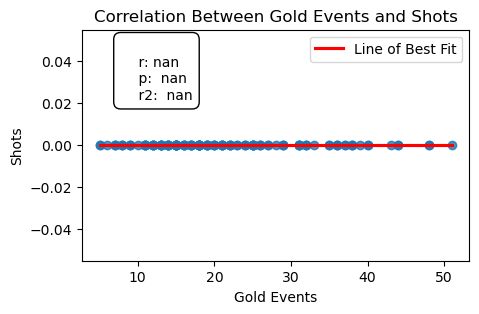

In [133]:
viz_corr(grp, "gold_events", "shots")

/var/folders/3_/17_jhz393j72f4q4hghx47f40000gn/T/ipykernel_40872/1164130373.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,p = stats.pearsonr(df[x], df[y])


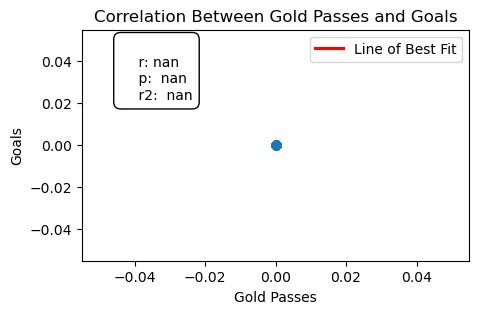

In [134]:
viz_corr(grp, "gold_passes", "goals")

/var/folders/3_/17_jhz393j72f4q4hghx47f40000gn/T/ipykernel_40872/1164130373.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,p = stats.pearsonr(df[x], df[y])


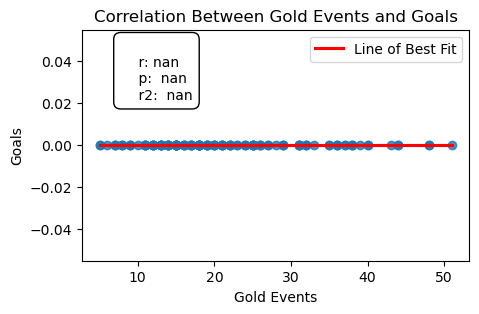

In [136]:
viz_corr(grp, "gold_events", "goals")